# EDA: shallow MCTS — v18 / v19 / v20

This notebook audits **how lookahead actually decides**, then checks whether those
mechanics show up in the round-robin. All three agents inherit `HeuristicV14` and run
the same shallow MCTS skeleton:

- **100 simulations / turn**, **5-turn** `LocalSim` rollouts, greedy type-aware rollout policy
- Each simulation uses **revealed** moves only (the Showdown sets JSON is not loaded)
- Root children are legal moves **and** switches; the played action is the child with
  most visits

They differ in *leaf evaluation*, *pre-search overrides*, and *how the tree is biased*:

| | **v18** (`HeuristicV18MCTS`) | **v19** (`HeuristicV19MCTS`) | **v20** (`HeuristicV20MCTSHybrid`) |
|---|---|---|---|
| Tree policy | UCB1, $C=1.4$ | UCB1, $C=1.4$ | **PUCT** with v14 prior **0.70** |
| Leaf eval | Team HP + boosts + status + hazards | + roles, speed-tier OHKO threat, richer status/hazards | Same as v19 |
| Before search | Guaranteed KO only | KO → endgame (≤2 mons) → setup-sweeper stop → status absorb | Same as v19, and **takes** the early U-turn / Volt Switch |
| v14 relationship | Probe *after* search to log `search_diff` | Same probe | v14 action is the **PUCT prior**, then search may still override |
| What “lookahead worked” means | `search_diff_us` > 0: MCTS played a *different* action than v14 | Same | Same, but PUCT should make overrides **rarer** |

```
Every turn
──────────
forced faint? ────────── v14 best-switch
guaranteed KO? ───────── take it (no tree)
[v19/v20] endgame / setup-stop / absorb?
                    │
         shallow MCTS (100×)
         for each sim:
           use revealed moves only
           pick root child by UCB1 / PUCT
           LocalSim.step × 5 (greedy rollout)
           leaf score → backprop
         play argmax visits
         [loop guard if switched last turn]
         log search_diff vs a fresh v14 probe
```

**Sample size.** Every file that involves v18/v19/v20 is **1,000 games** (not 10k).
Each agent therefore has 28,000 games as *us*. A 95% Wilson interval at p ≈ 0.5 is
**±3.1 pp per matchup** and **±0.58 pp** on the 28k overall. Gaps under ~3 pp in a
single cell are noise.

Benchmark: `data/benchmarks/all_10k/gen9randombattle`.


In [1]:
# Setup
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data/benchmarks/all_10k/gen9randombattle").exists():
    ROOT = ROOT.parent
BENCHMARK_DIR = ROOT / "data/benchmarks/all_10k/gen9randombattle"
OUTPUT_DIR = ROOT / "src/p00_core/reporting/agents/mcts_v18_v20"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AGENTS = ["v18", "v19", "v20"]
AGENT_LABEL = {
    "v18": "v18 UCB1 (HP leaf)",
    "v19": "v19 UCB1 (positional leaf)",
    "v20": "v20 PUCT (v14 prior 0.70)",
}
AGENT_COLOR = {"v18": "#B03A2E", "v19": "#1A7A6D", "v20": "#3D5A80"}

PARADIGM_MAP = {
    "random": "Baseline",
    "max_power": "Baseline",
    "abyssal": "Baseline",
    "one_step": "Baseline",
    "safe_one_step": "Baseline",
    "simple_heuristic": "Baseline",
    **{f"v{i}": "Heuristic" for i in range(1, 15)},
    "v15": "Minimax",
    "v16": "Minimax",
    "v17": "Minimax",
    "v18": "MCTS",
    "v19": "MCTS",
    "v20": "MCTS",
    "v21": "IL Hybrid",
    "v22": "IL Pure",
}
PARADIGM_ORDER = ["Baseline", "Heuristic", "Minimax", "MCTS", "IL Hybrid", "IL Pure"]

SEARCH_COLS = [
    "search_moves_us", "search_switches_us", "search_diff_us",
    "endgame_solves_us", "ko_checks_us", "loop_guards_us", "total_turns_us",
]

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (11, 5.5), "font.size": 11, "savefig.dpi": 160})


def wilson_ci(wins: float, n: float, z: float = 1.96) -> float:
    """Half-width of a 95% Wilson interval, in percentage points."""
    if n <= 0:
        return 0.0
    p = wins / n
    denom = 1.0 + z * z / n
    margin = z * np.sqrt((p * (1 - p) + z * z / (4 * n)) / n) / denom
    return float(margin * 100)


print(f"Root        : {ROOT}")
print(f"Benchmark   : {BENCHMARK_DIR}")
print(f"Export      : {OUTPUT_DIR}")
print(f"Agents      : {AGENTS}")
print("Budget      : N_SIMULATIONS=100, ROLLOUT_DEPTH=5, C=1.4")
print("Note        : all v18/v19/v20 matchups are n=1,000")


Root        : /home/sirp/Documents/MUDS/TFM_Pokemon
Benchmark   : /home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k/gen9randombattle
Export      : /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/mcts_v18_v20
Agents      : ['v18', 'v19', 'v20']
Budget      : N_SIMULATIONS=100, ROLLOUT_DEPTH=5, C=1.4
Note        : all v18/v19/v20 matchups are n=1,000


## 1 · Load all three agents as *us*

Each row is one finished battle. Search telemetry (`search_*`, `search_diff_us`) is
written by the worker from the agent's per-battle counters.


In [2]:
# Load v18 / v19 / v20 as player
INT_FILL = [
    "won", "turns", "decisions_us", "fallback_moves_us", "error_moves_us",
    "fainted_us", "remaining_pokemon_us", "fainted_opp", "remaining_pokemon_opp",
    "voluntary_switches_us", "forced_switches_us",
    "supereffective_us", "hazard_sets_us", "setup_uses_us", "ko_checks_us",
    "terastallized_us", "loop_guards_us", *SEARCH_COLS,
]


def load_agent(agent: str) -> pd.DataFrame:
    files = sorted(BENCHMARK_DIR.glob(f"{agent}_vs_*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs for {agent} in {BENCHMARK_DIR}")
    parts = []
    for path in files:
        df = pd.read_csv(path)
        df["agent"] = agent
        df["matchup_opponent"] = df["opponent"]
        parts.append(df)
    out = pd.concat(parts, ignore_index=True)
    for col in INT_FILL:
        if col not in out.columns:
            out[col] = 0
        else:
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0)
    out["won_bool"] = out["won"].astype(int)
    out["opponent_paradigm"] = out["matchup_opponent"].map(lambda x: PARADIGM_MAP.get(x, "Other"))
    out["search_decisions"] = out["search_moves_us"] + out["search_switches_us"]
    turns = out["total_turns_us"].replace(0, np.nan)
    out["search_fire_rate"] = out["search_decisions"] / turns
    out["search_diff_rate"] = out["search_diff_us"] / turns
    out["override_of_search"] = out["search_diff_us"] / out["search_decisions"].replace(0, np.nan)
    out["search_switch_share"] = out["search_switches_us"] / out["search_decisions"].replace(0, np.nan)
    out["ko_rate"] = out["ko_checks_us"] / turns
    return out


frames = {ag: load_agent(ag) for ag in AGENTS}
df = pd.concat(frames.values(), ignore_index=True)

print("Games loaded")
for ag, g in frames.items():
    n_files = g.groupby("matchup_opponent").ngroups
    n_per = int(g.groupby("matchup_opponent").size().median())
    print(f"  {ag}: {len(g):>8,} games  |  {n_files} opponents × {n_per}  |  WR {g['won_bool'].mean()*100:.2f}%")
print(f"  total: {len(df):,} rows  |  columns {df.shape[1]}")


Games loaded
  v18:   28,000 games  |  28 opponents × 1000  |  WR 54.02%
  v19:   28,000 games  |  28 opponents × 1000  |  WR 53.29%
  v20:   28,000 games  |  28 opponents × 1000  |  WR 59.66%
  total: 84,000 rows  |  columns 80


## 2 · Headline: same budget, three search policies

If leaf evaluation and PUCT priors did not matter, overall win rate, search-fire rate,
and `search_diff` would line up. The interesting comparison is **v18 vs v19** (does a
richer 5-turn leaf help?) and **v19 vs v20** (does biasing the tree toward v14 help?).


In [3]:
# Headline table
rows = []
for ag, g in frames.items():
    n = len(g)
    wins = int(g["won_bool"].sum())
    rows.append({
        "agent": AGENT_LABEL[ag],
        "games": n,
        "win_rate_%": 100 * wins / n,
        "ci95_pp": wilson_ci(wins, n),
        "avg_turns": g["turns"].mean(),
        "avg_hp_us": g["remaining_pokemon_us"].mean(),
        "search_fire_%_turns": 100 * g["search_fire_rate"].mean(),
        "search_moves / game": g["search_moves_us"].mean(),
        "search_switches / game": g["search_switches_us"].mean(),
        "search_diff / game": g["search_diff_us"].mean(),
        "override_%_of_search": 100 * g["override_of_search"].mean(),
        "ko_checks / game": g["ko_checks_us"].mean(),
        "endgame / game": g["endgame_solves_us"].mean(),
        "loop_guards / game": g["loop_guards_us"].mean(),
        "setup / game": g["setup_uses_us"].mean(),
        "hazards / game": g["hazard_sets_us"].mean(),
        "tera / game": g["terastallized_us"].mean(),
    })

headline = pd.DataFrame(rows).set_index("agent")
headline.to_csv(OUTPUT_DIR / "mcts_headline_comparison.csv")
headline.T


## 3 · Who actually chose the action? KO short-circuit vs 5-turn search

A guaranteed KO is resolved **before** the tree. If that path fires on most turns, the
agent is not “looking 5 turns ahead” — it is v14’s damage calculator with a search
backup. `search_fire_rate` is the share of turns that reached MCTS.
`ko_checks_us` counts KO short-circuits (v18/v19/v20 all run `_find_guaranteed_ko`).

`endgame_solves_us` on **v18** is mostly contamination from the post-search v14 probe
(v18 never calls the endgame solver). On v19/v20 the solver really runs before search.


Mean counts per game
                      v18    v19    v20
ko_checks_us       14.163 14.193 14.543
search_moves_us     3.756  3.397  2.604
search_switches_us  0.608  0.873  1.069
search_diff_us      3.126  3.073  0.787
endgame_solves_us   0.033  0.029  0.028
loop_guards_us      0.098  0.260  0.347
search_fire_rate    0.181  0.176  0.155

Search fire rate (fraction of turns that reached the tree)
  v18: 18.1% of turns   KO checks 14.16/game
  v19: 17.6% of turns   KO checks 14.19/game
  v20: 15.5% of turns   KO checks 14.54/game


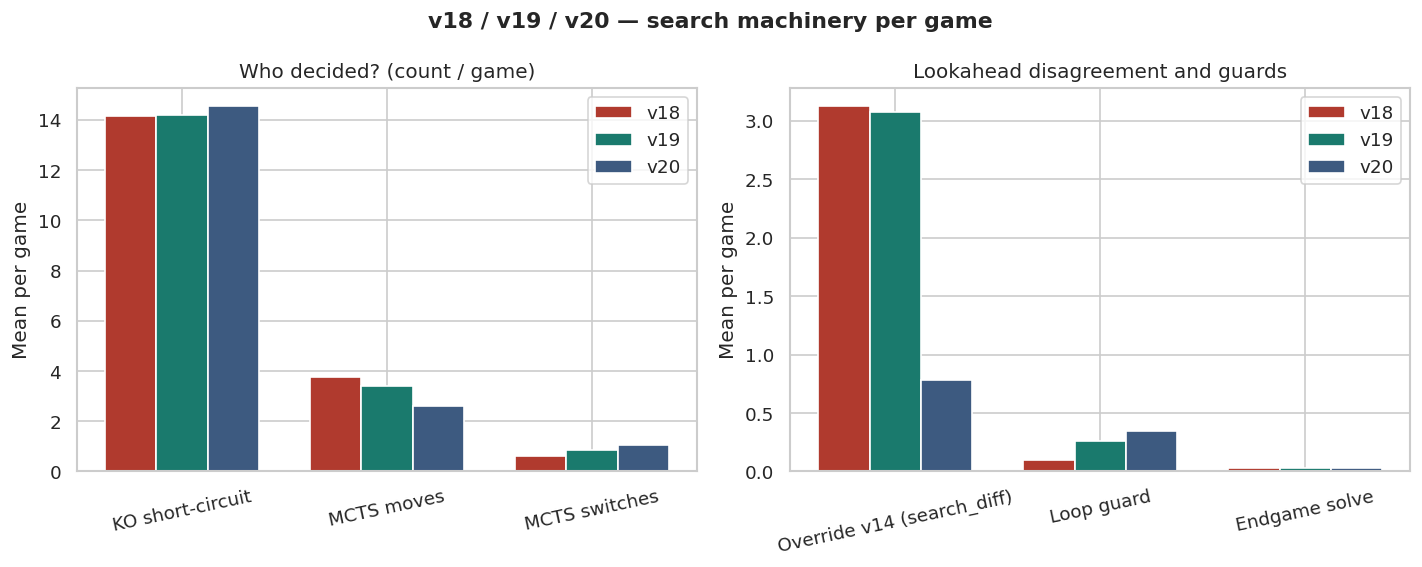

In [4]:
# Decision machinery per game
fp_cols = [
    "ko_checks_us", "search_moves_us", "search_switches_us",
    "search_diff_us", "endgame_solves_us", "loop_guards_us",
]
fp = pd.DataFrame({ag: frames[ag][fp_cols].mean() for ag in AGENTS}).T
fp["search_fire_rate"] = pd.Series({ag: frames[ag]["search_fire_rate"].mean() for ag in AGENTS})
print("Mean counts per game")
print(fp.T.to_string())

print("\nSearch fire rate (fraction of turns that reached the tree)")
for ag, g in frames.items():
    print(f"  {ag}: {100*g['search_fire_rate'].mean():.1f}% of turns   "
          f"KO checks {g['ko_checks_us'].mean():.2f}/game")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
x = np.arange(3)
w = 0.25
left = ["ko_checks_us", "search_moves_us", "search_switches_us"]
for i, ag in enumerate(AGENTS):
    axes[0].bar(x + (i - 1) * w, [frames[ag][c].mean() for c in left], w,
                color=AGENT_COLOR[ag], label=ag)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["KO short-circuit", "MCTS moves", "MCTS switches"], rotation=12)
axes[0].set_ylabel("Mean per game")
axes[0].set_title("Who decided? (count / game)")
axes[0].legend()

right = ["search_diff_us", "loop_guards_us", "endgame_solves_us"]
for i, ag in enumerate(AGENTS):
    axes[1].bar(x + (i - 1) * w, [frames[ag][c].mean() for c in right], w,
                color=AGENT_COLOR[ag], label=ag)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Override v14 (search_diff)", "Loop guard", "Endgame solve"], rotation=12)
axes[1].set_ylabel("Mean per game")
axes[1].set_title("Lookahead disagreement and guards")
axes[1].legend()

fig.suptitle("v18 / v19 / v20 — search machinery per game", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mcts_fingerprint_bars.png")
plt.show()


## 4 · When lookahead overrides the heuristic (`search_diff`)

`search_diff_us` increments when the action MCTS played is **not** the action a fresh
v14 probe would have played. That is the empirical definition of “the 5-turn tree
disagreed with one-ply expert knowledge”.

- **High override + lower win rate** ⇒ horizon effect: the tree prefers a short-term
  leaf score over v14’s long-horizon rules (hazards, sweeper preservation).
- **Low override + higher win rate** ⇒ PUCT is mostly *re-ranking v14*, not replacing it.

Split `search_diff_rate` by win/loss. If losers overrode more, unconstrained lookahead
is hurting.


Override among search decisions, and search_diff/turn in wins vs losses
agent    override%   diff/turn W   diff/turn L   Δ (L−W)
v18           71.3         0.109         0.152    +0.043
v19           71.1         0.104         0.152    +0.049
v20           18.7         0.029         0.038    +0.009


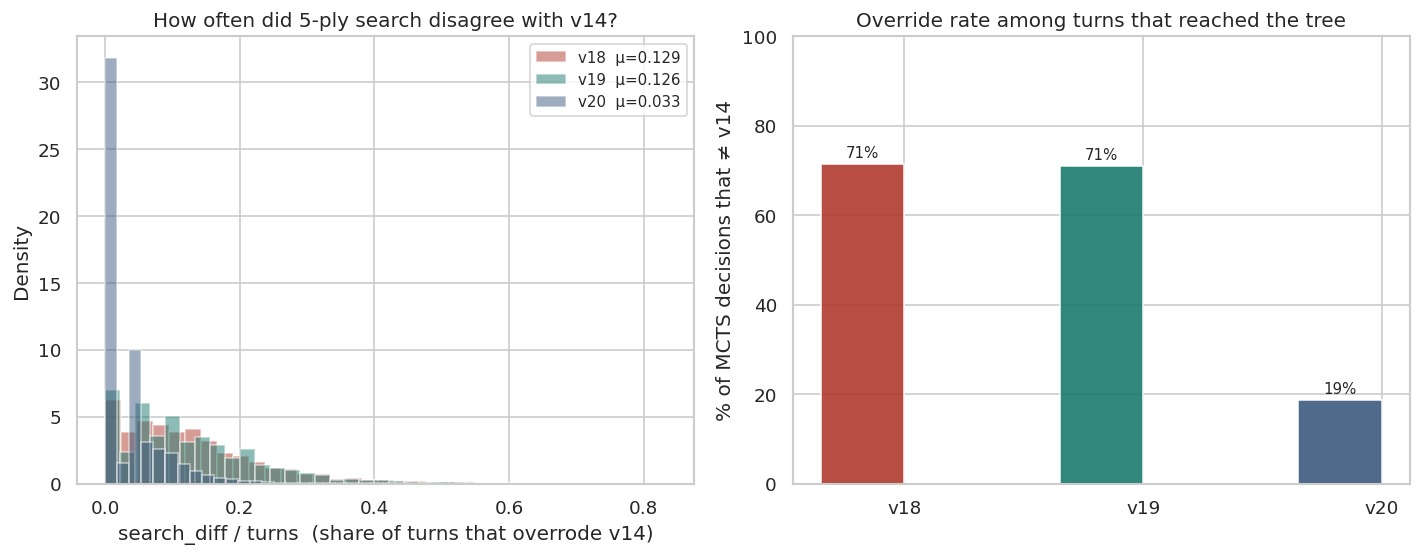

In [5]:
# Override distributions and win/loss split
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ag, g in frames.items():
    vals = g["search_diff_rate"].dropna()
    axes[0].hist(vals, bins=35, density=True, alpha=0.5, color=AGENT_COLOR[ag],
                 label=f"{ag}  μ={vals.mean():.3f}")
axes[0].set_xlabel("search_diff / turns  (share of turns that overrode v14)")
axes[0].set_ylabel("Density")
axes[0].set_title("How often did 5-ply search disagree with v14?")
axes[0].legend(fontsize=9)

# grouped bars: override rate of search decisions, and search_diff_rate in wins vs losses
labels = AGENTS
x = np.arange(len(labels))
w = 0.35
ov = [100 * frames[ag]["override_of_search"].mean() for ag in AGENTS]
axes[1].bar(x - w / 2, ov, w, color=[AGENT_COLOR[ag] for ag in AGENTS], alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("% of MCTS decisions that ≠ v14")
axes[1].set_title("Override rate among turns that reached the tree")
axes[1].set_ylim(0, 100)
for i, v in enumerate(ov):
    axes[1].text(i - w / 2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mcts_override.png")
plt.show()

print("Override among search decisions, and search_diff/turn in wins vs losses")
print(f"{'agent':<6}  {'override%':>10}  {'diff/turn W':>12}  {'diff/turn L':>12}  {'Δ (L−W)':>8}")
for ag, g in frames.items():
    w = g[g["won_bool"] == 1]["search_diff_rate"].mean()
    l = g[g["won_bool"] == 0]["search_diff_rate"].mean()
    print(f"{ag:<6}  {100*g['override_of_search'].mean():10.1f}  {w:12.3f}  {l:12.3f}  {l-w:+8.3f}")


## 5 · Does 5-ply search value the future? Setup, hazards, Tera

The reason to search 5 turns instead of 1-ply minimax is **delayed payoff**: Dragon
Dance, Stealth Rock, recovery. If the greedy rollout + HP leaf still treat those as
low value, `setup_uses_us` and `hazard_sets_us` will stay at v14 levels (~0.2 setup,
~0.04 hazards) rather than v9/v12 levels (~1.6 setup). That is the horizon effect in
the replay, not in the algorithm description.


  setup_uses_us             v18=0.223  v19=0.219  v20=0.202
  hazard_sets_us            v18=0.046  v19=0.047  v20=0.035
  terastallized_us          v18=0.406  v19=0.394  v20=0.388
  voluntary_switches_us     v18=1.605  v19=1.898  v20=2.091
  supereffective_us         v18=4.190  v19=4.215  v20=4.446

Reference (from the heuristic/IL notebooks, not reloaded here):
  v12 setup ≈ 1.73, hazards ≈ 0.18, tera ≈ 0.95
  v14 setup ≈ 0.22, hazards ≈ 0.03, tera ≈ 0.31, ko_checks ≈ 15


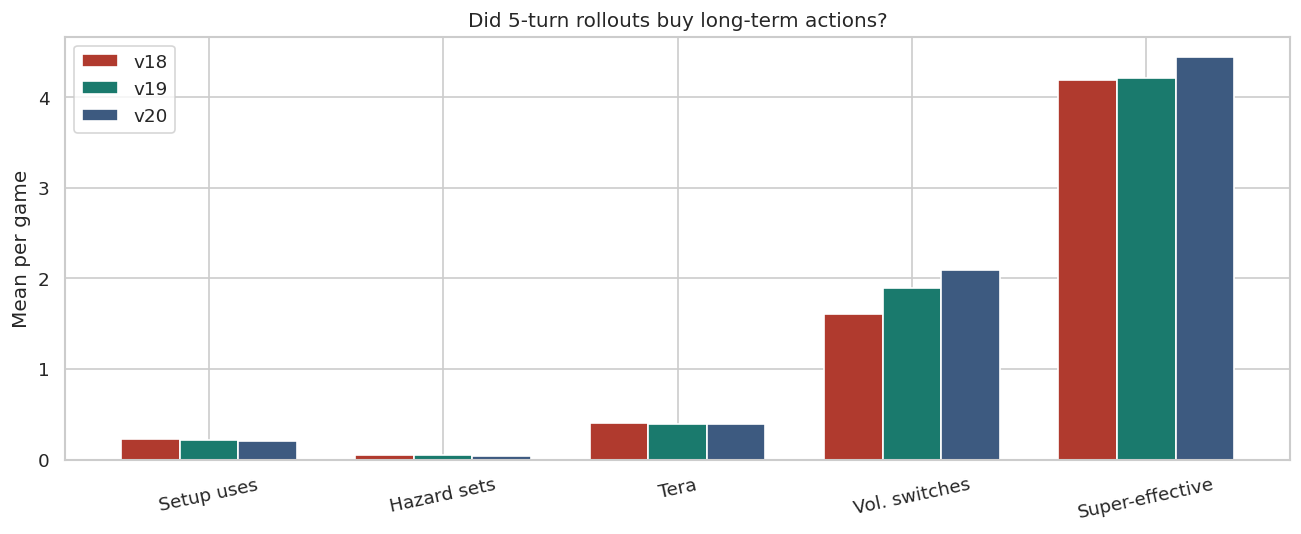

In [6]:
# Future-payoff proxies
proxy = ["setup_uses_us", "hazard_sets_us", "terastallized_us",
         "voluntary_switches_us", "supereffective_us"]
fig, ax = plt.subplots(figsize=(11, 4.6))
idx = np.arange(len(proxy))
w = 0.25
for i, ag in enumerate(AGENTS):
    ax.bar(idx + (i - 1) * w, [frames[ag][c].mean() for c in proxy], w,
           color=AGENT_COLOR[ag], label=ag)
ax.set_xticks(idx)
ax.set_xticklabels(["Setup uses", "Hazard sets", "Tera", "Vol. switches", "Super-effective"],
                   rotation=12)
ax.set_ylabel("Mean per game")
ax.set_title("Did 5-turn rollouts buy long-term actions?")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mcts_future_proxies.png")
plt.show()

for c in proxy:
    vals = "  ".join(f"{ag}={frames[ag][c].mean():.3f}" for ag in AGENTS)
    print(f"  {c:24s}  {vals}")
print("\nReference (from the heuristic/IL notebooks, not reloaded here):")
print("  v12 setup ≈ 1.73, hazards ≈ 0.18, tera ≈ 0.95")
print("  v14 setup ≈ 0.22, hazards ≈ 0.03, tera ≈ 0.31, ko_checks ≈ 15")


## 6 · Win rate across the same opponents

Grouped bars against every opponent. All cells are 1,000 games; error bars are 95%
Wilson intervals (~±3 pp). The discriminating opponents are **v12 / v13 / v14**
(knowledge ceiling) and **Abyssal**.


v20 beats v18 in 28 / 28 matchups
Mean delta (v20 − v18): +5.64 pp

Largest PUCT gains (v20 − v18):
matchup_opponent
v17   11.100
v13   10.500
v15    9.800
v12    8.700
v9     8.500
v11    8.200

Where unconstrained UCB1 (v18) is closer or ahead:
matchup_opponent
random      0.300
v3          0.900
v22         1.900
max_power   2.100
one_step    3.300
v7          3.600


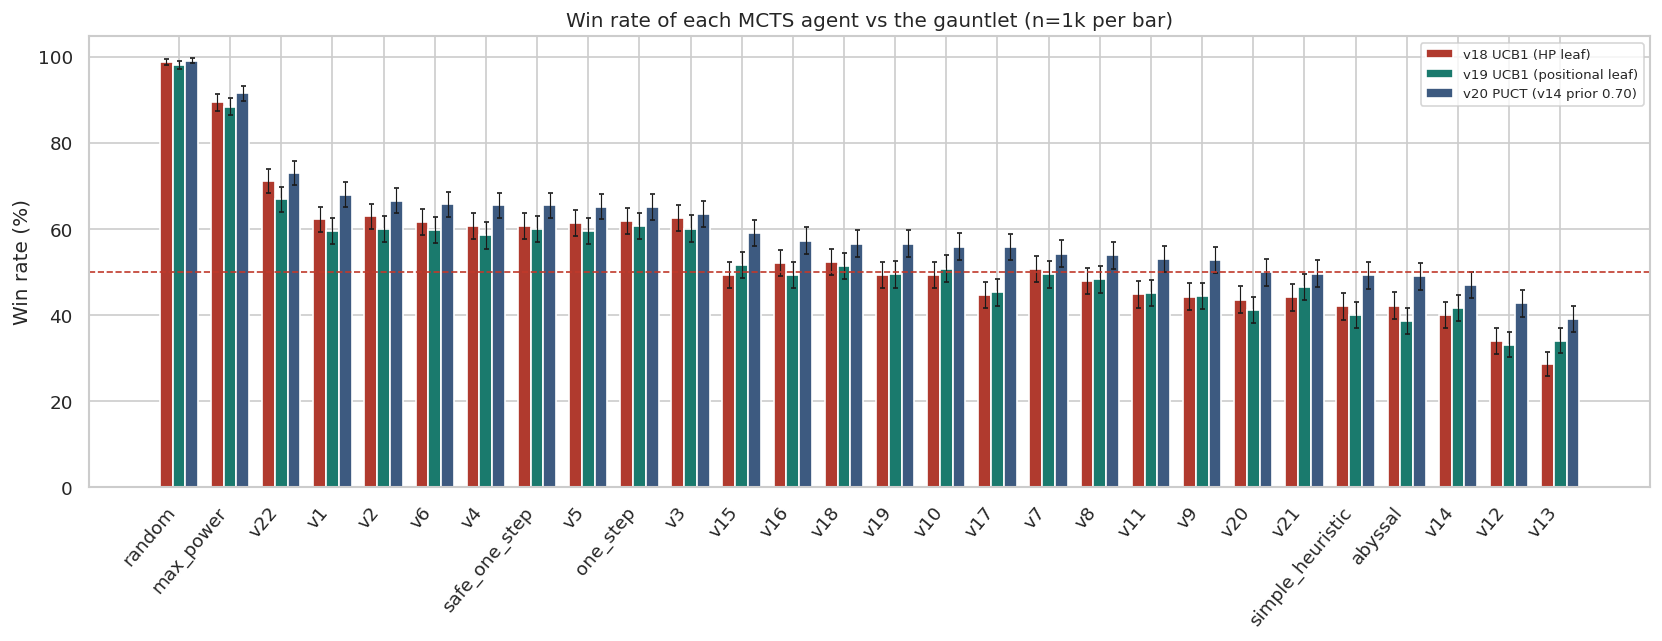

In [7]:
# Per-opponent win rates
def wr_table(g: pd.DataFrame) -> pd.DataFrame:
    t = g.groupby("matchup_opponent").agg(games=("won_bool", "size"), wins=("won_bool", "sum"))
    t["win_rate"] = 100 * t["wins"] / t["games"]
    t["ci95"] = [wilson_ci(w, n) for w, n in zip(t["wins"], t["games"])]
    t["paradigm"] = t.index.map(lambda x: PARADIGM_MAP.get(x, "Other"))
    return t


wr = {ag: wr_table(g) for ag, g in frames.items()}
cmp = wr["v18"].add_prefix("v18_")
for ag in ("v19", "v20"):
    cmp = cmp.join(wr[ag].add_prefix(f"{ag}_"), how="outer")
cmp["delta_v20_v18"] = cmp["v20_win_rate"] - cmp["v18_win_rate"]
cmp = cmp.sort_values("v20_win_rate", ascending=False)
cmp.to_csv(OUTPUT_DIR / "mcts_winrate_by_opponent.csv")

order = list(cmp.index)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(14, 5.5))
w = 0.25
for i, ag in enumerate(AGENTS):
    ax.bar(x + (i - 1) * w, cmp.loc[order, f"{ag}_win_rate"], w,
           yerr=cmp.loc[order, f"{ag}_ci95"], capsize=1.5,
           color=AGENT_COLOR[ag], label=AGENT_LABEL[ag], error_kw={"elinewidth": 0.7})
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=50, ha="right")
ax.set_ylabel("Win rate (%)")
ax.set_title("Win rate of each MCTS agent vs the gauntlet (n=1k per bar)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mcts_winrate_grouped.png")
plt.show()

print(f"v20 beats v18 in {(cmp['delta_v20_v18'] > 0).sum()} / {len(cmp)} matchups")
print(f"Mean delta (v20 − v18): {cmp['delta_v20_v18'].mean():+.2f} pp")
print("\nLargest PUCT gains (v20 − v18):")
print(cmp["delta_v20_v18"].sort_values(ascending=False).head(6).to_string())
print("\nWhere unconstrained UCB1 (v18) is closer or ahead:")
print(cmp["delta_v20_v18"].sort_values().head(6).to_string())


## 7 · Head-to-head among the three search agents

Independent 1k samples, not flipped games. Reciprocals should sum near 1. v18 vs v19
tests the leaf evaluator; v19 vs v20 tests PUCT.


In [8]:
# Direct H2H triangle
h2h_rows = []
for a in AGENTS:
    for b in AGENTS:
        if a == b:
            continue
        sub = frames[a][frames[a]["matchup_opponent"] == b]
        n, w = len(sub), int(sub["won_bool"].sum())
        h2h_rows.append({
            "file": f"{a}_vs_{b}",
            "games": n,
            "win_rate_%": 100 * w / n,
            "ci95_pp": wilson_ci(w, n),
            "search_diff / game": sub["search_diff_us"].mean(),
            "override_%": 100 * sub["override_of_search"].mean(),
            "search_fire_%": 100 * sub["search_fire_rate"].mean(),
        })
h2h_df = pd.DataFrame(h2h_rows).set_index("file")
print(h2h_df.to_string())
print()
for a, b in (("v18", "v19"), ("v18", "v20"), ("v19", "v20")):
    s = (h2h_df.loc[f"{a}_vs_{b}", "win_rate_%"] + h2h_df.loc[f"{b}_vs_{a}", "win_rate_%"]) / 100
    print(f"  WR({a} vs {b}) + WR({b} vs {a}) = {s:.4f}")


            games  win_rate_%  ci95_pp  search_diff / game  override_%  search_fire_%
file                                                                                 
v18_vs_v19   1000      49.300    3.093               2.848      71.697         17.378
v18_vs_v20   1000      43.600    3.068               2.845      68.246         17.952
v19_vs_v18   1000      51.400    3.092               2.831      71.600         17.164
v19_vs_v20   1000      41.200    3.045               2.844      69.185         17.387
v20_vs_v18   1000      56.600    3.066               0.791      18.995         15.991
v20_vs_v19   1000      56.600    3.066               0.827      19.403         15.561

  WR(v18 vs v19) + WR(v19 vs v18) = 1.0070
  WR(v18 vs v20) + WR(v20 vs v18) = 1.0020
  WR(v19 vs v20) + WR(v20 vs v19) = 0.9780


## 8 · Strength by opponent paradigm

Does lookahead help against knowledge-heavy heuristics (v12–v14), against 1-ply
minimax, or only against weak baselines and pure IL?


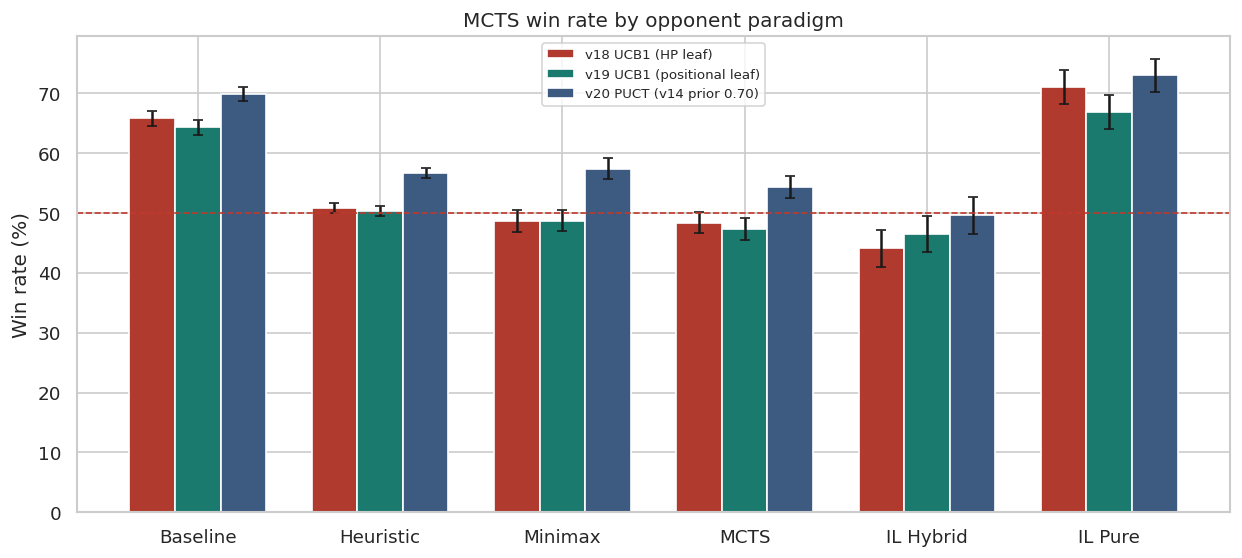

In [9]:
# Paradigm-level WR
def paradigm_wr(g: pd.DataFrame) -> pd.DataFrame:
    t = g.groupby("opponent_paradigm").agg(games=("won_bool", "size"), wins=("won_bool", "sum"))
    t["win_rate"] = 100 * t["wins"] / t["games"]
    t["ci95"] = [wilson_ci(w, n) for w, n in zip(t["wins"], t["games"])]
    return t.reindex([p for p in PARADIGM_ORDER if p in t.index])


pw = {ag: paradigm_wr(g) for ag, g in frames.items()}
labels = list(pw["v18"].index)
x = np.arange(len(labels))
w = 0.25
fig, ax = plt.subplots(figsize=(10.5, 4.8))
for i, ag in enumerate(AGENTS):
    ax.bar(x + (i - 1) * w, pw[ag]["win_rate"], w, yerr=pw[ag]["ci95"],
           capsize=3, color=AGENT_COLOR[ag], label=AGENT_LABEL[ag])
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Win rate (%)")
ax.set_title("MCTS win rate by opponent paradigm")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mcts_wr_by_paradigm.png")
plt.show()

joined = pw["v18"].add_prefix("v18_")
for ag in ("v19", "v20"):
    joined = joined.join(pw[ag].add_prefix(f"{ag}_"))
joined


## 9 · Discriminating matchups: v12, v14, Abyssal, v21

v12 is the bot-vs-bot knowledge ceiling. v14 is the teacher inside every MCTS agent.
If 5-ply search beat its own leaf / prior, v20 vs v14 would be clearly above 50%.


                   paradigm  v18_wr  v18_ci  v19_wr  v19_ci  v20_wr  v20_ci
opponent                                                                   
v12               Heuristic  34.000   2.931  33.100   2.912  42.700   3.060
v13               Heuristic  28.600   2.797  34.100   2.933  39.100   3.019
v14               Heuristic  40.000   3.031  41.700   3.050  47.000   3.088
abyssal            Baseline  42.200   3.055  38.700   3.013  49.000   3.092
simple_heuristic   Baseline  42.000   3.053  40.100   3.032  49.200   3.093
v15                 Minimax  49.300   3.093  51.600   3.092  59.100   3.042
v17                 Minimax  44.700   3.076  45.300   3.079  55.800   3.072
v21               IL Hybrid  44.100   3.072  46.500   3.086  49.600   3.093
v22                 IL Pure  71.100   2.805  66.900   2.912  73.000   2.748


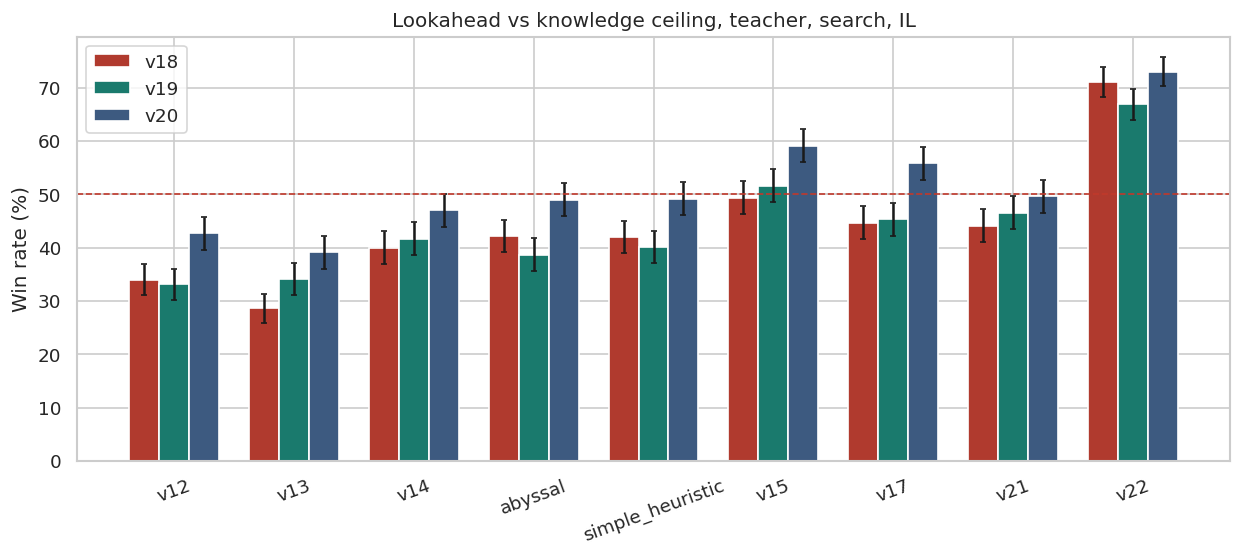

In [10]:
# Key matchup table
keys = ["v12", "v13", "v14", "abyssal", "simple_heuristic", "v15", "v17", "v21", "v22"]
rows = []
for opp in keys:
    rec = {"opponent": opp, "paradigm": PARADIGM_MAP.get(opp, "?")}
    for ag in AGENTS:
        sub = wr[ag].loc[opp] if opp in wr[ag].index else None
        rec[f"{ag}_wr"] = float(sub["win_rate"]) if sub is not None else np.nan
        rec[f"{ag}_ci"] = float(sub["ci95"]) if sub is not None else np.nan
    rows.append(rec)
key_df = pd.DataFrame(rows).set_index("opponent")
print(key_df.to_string())

fig, ax = plt.subplots(figsize=(10.5, 4.8))
idx = np.arange(len(keys))
w = 0.25
for i, ag in enumerate(AGENTS):
    ax.bar(idx + (i - 1) * w, [key_df.loc[k, f"{ag}_wr"] for k in keys], w,
           yerr=[key_df.loc[k, f"{ag}_ci"] for k in keys], capsize=2,
           color=AGENT_COLOR[ag], label=ag)
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(idx)
ax.set_xticklabels(keys, rotation=20)
ax.set_ylabel("Win rate (%)")
ax.set_title("Lookahead vs knowledge ceiling, teacher, search, IL")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mcts_key_matchups.png")
plt.show()


## 10 · Switching that came from the tree

v19’s richer leaf and v20’s prior both change *which* root children get visits.
`search_switches_us` is switches the tree actually picked (not forced faints).
v20’s higher search-switch share with *lower* `search_diff` means PUCT is steering
visits toward v14’s switch, not inventing new ones.


Means
  voluntary_switches_us       v18=1.605  v19=1.898  v20=2.091
  search_switches_us          v18=0.608  v19=0.873  v20=1.069
  search_switch_share         v18=0.136  v19=0.206  v20=0.362
  loop_guards_us              v18=0.098  v19=0.260  v20=0.347


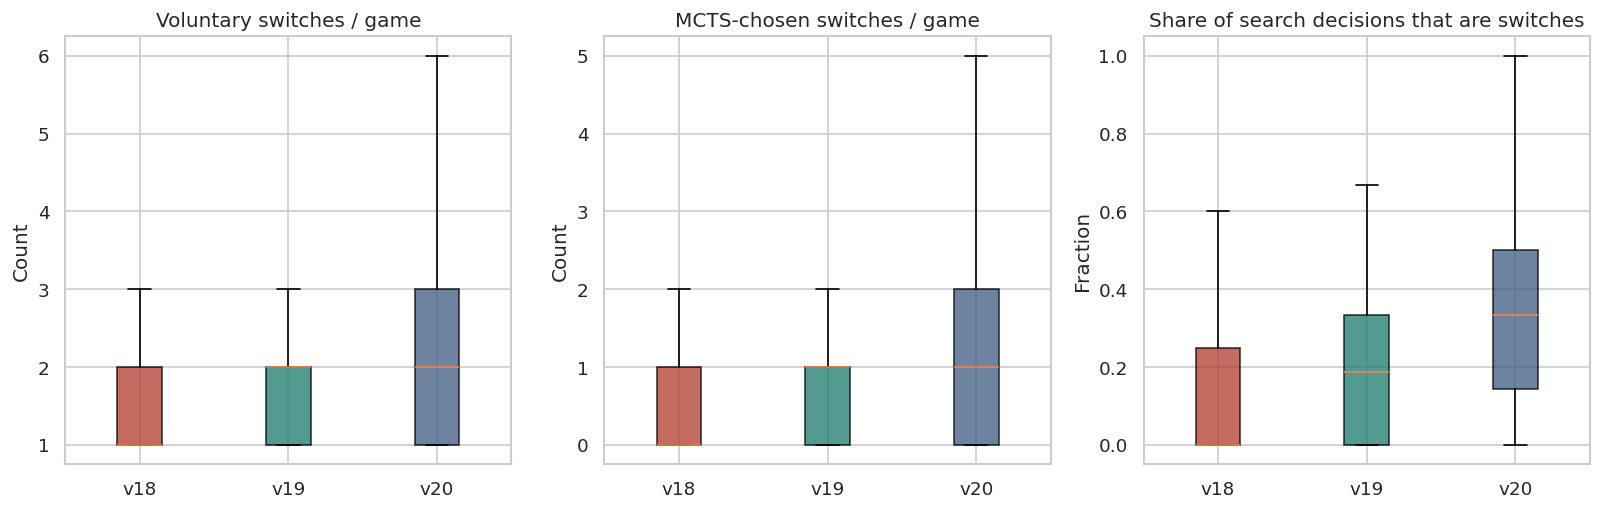

In [11]:
# Switching from search
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, col, title in [
    (axes[0], "voluntary_switches_us", "Voluntary switches / game"),
    (axes[1], "search_switches_us", "MCTS-chosen switches / game"),
    (axes[2], "search_switch_share", "Share of search decisions that are switches"),
]:
    data = [frames[ag][col].dropna() for ag in AGENTS]
    bp = ax.boxplot(data, tick_labels=AGENTS, patch_artist=True, showfliers=False)
    for patch, ag in zip(bp["boxes"], AGENTS):
        patch.set_facecolor(AGENT_COLOR[ag])
        patch.set_alpha(0.75)
    ax.set_title(title)
    if col == "search_switch_share":
        ax.set_ylabel("Fraction")
    else:
        ax.set_ylabel("Count")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mcts_switching_box.png")
plt.show()

print("Means")
for col in ["voluntary_switches_us", "search_switches_us", "search_switch_share", "loop_guards_us"]:
    vals = "  ".join(f"{ag}={frames[ag][col].mean():.3f}" for ag in AGENTS)
    print(f"  {col:26s}  {vals}")


## 11 · Game length and leftover HP

Unconstrained UCB1 that overrides v14 often should either snatch extra KOs (shorter
games, more remaining HP) or wander (longer games, less HP). PUCT hugging v14 should
look like v14.


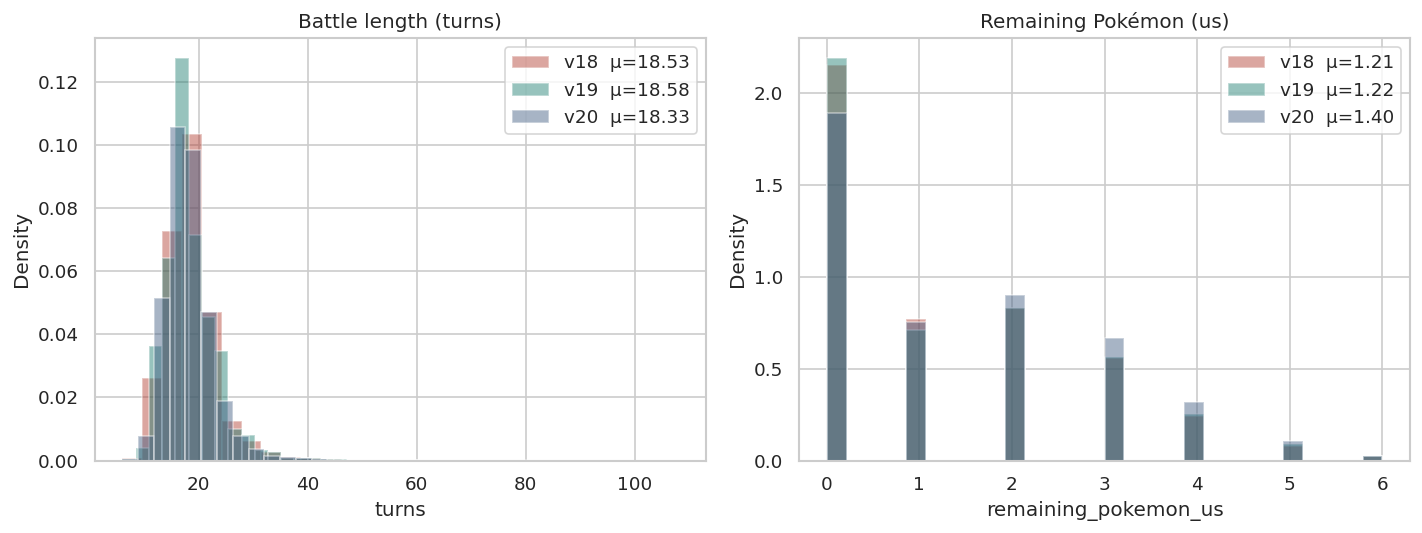

In [12]:
# Duration and leftover HP
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, col, title in [
    (axes[0], "turns", "Battle length (turns)"),
    (axes[1], "remaining_pokemon_us", "Remaining Pokémon (us)"),
]:
    for ag, g in frames.items():
        ax.hist(g[col], bins=28, density=True, alpha=0.45, color=AGENT_COLOR[ag],
                label=f"{ag}  μ={g[col].mean():.2f}")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mcts_length_hp.png")
plt.show()


## 12 · Self-play sanity

Each agent vs itself should sit near 50% (n = 1,000 ⇒ ±3.1 pp).


In [13]:
# Self-play
for ag, g in frames.items():
    sub = g[g["matchup_opponent"] == ag]
    n, w = len(sub), int(sub["won_bool"].sum())
    print(f"  {ag} vs {ag}:  {100*w/n:.2f}%  ±{wilson_ci(w, n):.2f}  (n={n:,})")


  v18 vs v18:  52.30%  ±3.09  (n=1,000)
  v19 vs v19:  49.50%  ±3.09  (n=1,000)
  v20 vs v20:  49.90%  ±3.09  (n=1,000)


## 13 · Export comparison report


In [14]:
# Markdown report
def wr_of(ag, opp):
    return float(wr[ag].loc[opp, "win_rate"])


lines = [
    "# shallow MCTS EDA — v18 / v19 / v20",
    "",
    "Source: `data/benchmarks/all_10k/gen9randombattle` (each agent as us vs 28 opponents, **1k games**).",
    "Budget: 100 simulations / turn, 5-turn LocalSim rollouts, C = 1.4.",
    "",
    "## Architecture in one paragraph",
    "",
    "All three agents are shallow MCTS on top of HeuristicV14. Each simulation",
    "fills revealed-move slots (sets JSON is not loaded), rolls out 5 turns with a greedy type-aware policy,",
    "and backs up a leaf score. **v18** uses UCB1 and a simple HP/boosts/status/hazards leaf.",
    "**v19** keeps UCB1 but scores leaves with roles and OHKO threats, and runs v14 tactical",
    "overrides (endgame, setup-stop, absorb) *before* the tree. **v20** is v19 with PUCT:",
    "the v14 action gets prior 0.70 so the 100 simulations concentrate on that line.",
    "",
    "## Headline",
    "",
    headline.to_markdown(),
    "",
    "## Lookahead vs the heuristic",
    "",
    "- Search only runs on **~16–18% of turns**; the rest are guaranteed-KO short-circuits",
    "  (~14 KO checks / game). Five-ply search is a backup, not the default policy.",
    "- Of the turns that *do* reach the tree, **v18/v19 override v14 on ~71%** of decisions.",
    "  Losers override more than winners (search_diff/turn 0.15 vs 0.11). That is the",
    "  horizon effect in the data: unconstrained 5-ply disagreement correlates with losing.",
    "- **v20 overrides on only ~19%** of search decisions and is the strongest MCTS agent",
    "  (overall +5.6 pp vs v18). PUCT is mostly re-ranking v14, not replacing it.",
    "- Setup / hazards stay at v14 levels (~0.22 / ~0.04), not v12 levels. Five greedy",
    "  rollout turns do **not** recover delayed-payoff strategy.",
    "",
    "## Head-to-head",
    "",
    h2h_df.to_markdown(),
    "",
    "## Discriminating matchups (WR %)",
    "",
    key_df.to_markdown(),
    "",
    "## Paradigm win rates",
    "",
    joined.to_markdown(),
    "",
    "## Figures",
    "",
    "- `mcts_fingerprint_bars.png`",
    "- `mcts_override.png`",
    "- `mcts_future_proxies.png`",
    "- `mcts_winrate_grouped.png`",
    "- `mcts_wr_by_paradigm.png`",
    "- `mcts_key_matchups.png`",
    "- `mcts_switching_box.png`",
    "- `mcts_length_hp.png`",
]

report_path = OUTPUT_DIR / "mcts_v18_v20_comparison.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {report_path}")
print(f"Plots in {OUTPUT_DIR}")


Wrote /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/mcts_v18_v20/mcts_v18_v20_comparison.md
Plots in /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/mcts_v18_v20
